In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load CSV file

df = pd.read_csv("AgentLogingReport.csv")

# Display first rows
df.head()

,SL No,Agent,Date,Login Time,Logout Time,Duration
0,1,Shivananda Sonwane,30-Jul-22,15:35:29,17:39:39,02:04:10
1,2,Khushboo Priya,30-Jul-22,15:06:59,15:07:16,00:00:17
2,3,Nandani Gupta,30-Jul-22,15:04:24,17:31:07,02:26:42
3,4,Hrisikesh Neogi,30-Jul-22,14:34:29,15:19:35,00:45:06
4,5,Mukesh,30-Jul-22,14:03:15,15:11:52,01:08:36


In [3]:
# Dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# Column names

df.columns

Rows: 1000
Columns: 6


Index(['SL No', 'Agent', 'Date', 'Login Time', 'Logout Time', 'Duration'], dtype='str')

In [4]:
# Check missing values

df.isnull().sum()

SL No          0
Agent          0
Date           0
Login Time     0
Logout Time    0
Duration       0
dtype: int64

In [5]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   SL No        1000 non-null   int64
 1   Agent        1000 non-null   str  
 2   Date         1000 non-null   str  
 3   Login Time   1000 non-null   str  
 4   Logout Time  1000 non-null   str  
 5   Duration     1000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 91.3 KB


In [6]:
# Select object/string columns

text_columns = df.select_dtypes(include=['object']).columns

text_columns

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_95362/760233262.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


Index(['Agent', 'Date', 'Login Time', 'Logout Time', 'Duration'], dtype='str')

In [7]:
# Combine all text columns into one column

df['combined_text'] = df[text_columns].fillna('').apply(
    lambda x: ' '.join(x.astype(str)),
    axis=1
)

df[['combined_text']].head()

,combined_text
0,Shivananda Sonwane 30-Jul-22 15:35:29 17:39:39...
1,Khushboo Priya 30-Jul-22 15:06:59 15:07:16 00:...
2,Nandani Gupta 30-Jul-22 15:04:24 17:31:07 02:2...
3,Hrisikesh Neogi 30-Jul-22 14:34:29 15:19:35 00...
4,Mukesh 30-Jul-22 14:03:15 15:11:52 01:08:36


In [8]:
# Stop words

stop_words = set(stopwords.words('english'))

# Lemmatizer

lemmatizer = WordNetLemmatizer()


def clean_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove numbers and symbols
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)


df['clean_text'] = df['combined_text'].apply(clean_text)


df[['clean_text']].head()

,clean_text
0,shivananda sonwane jul
1,khushboo priya jul
2,nandani gupta jul
3,hrisikesh neogi jul
4,mukesh jul


In [9]:
tfidf = TfidfVectorizer(
    max_features=1000
)


X = tfidf.fit_transform(df['clean_text'])


print(X.shape)

(1000, 78)


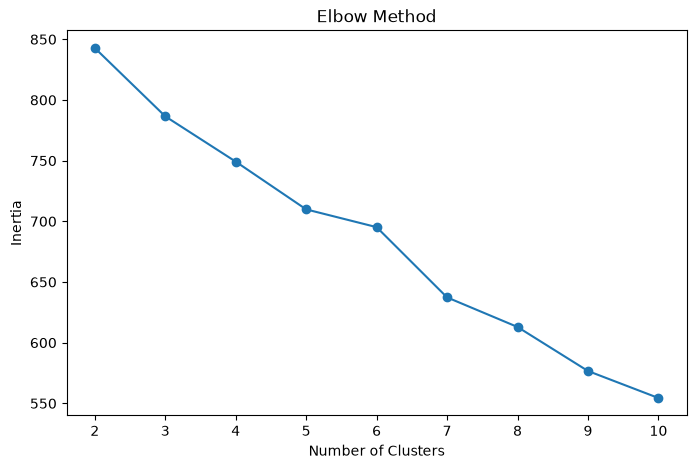

In [10]:
inertia = []

K = range(2,11)

for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)


clusters = kmeans.fit_predict(X)


df['Cluster'] = clusters


df.head()

,SL No,Agent,Date,Login Time,Logout Time,Duration,combined_text,clean_text,Cluster
0,1,Shivananda Sonwane,30-Jul-22,15:35:29,17:39:39,02:04:10,Shivananda Sonwane 30-Jul-22 15:35:29 17:39:39...,shivananda sonwane jul,1
1,2,Khushboo Priya,30-Jul-22,15:06:59,15:07:16,00:00:17,Khushboo Priya 30-Jul-22 15:06:59 15:07:16 00:...,khushboo priya jul,1
2,3,Nandani Gupta,30-Jul-22,15:04:24,17:31:07,02:26:42,Nandani Gupta 30-Jul-22 15:04:24 17:31:07 02:2...,nandani gupta jul,0
3,4,Hrisikesh Neogi,30-Jul-22,14:34:29,15:19:35,00:45:06,Hrisikesh Neogi 30-Jul-22 14:34:29 15:19:35 00...,hrisikesh neogi jul,1
4,5,Mukesh,30-Jul-22,14:03:15,15:11:52,01:08:36,Mukesh 30-Jul-22 14:03:15 15:11:52 01:08:36,mukesh jul,1


In [12]:
sil_score = silhouette_score(
    X,
    clusters
)


print(
    "Silhouette Score:",
    sil_score
)

Silhouette Score: 0.24776920986823353


In [13]:
df['Cluster'].value_counts()

Cluster
1    749
3    106
0     69
2     40
4     36
Name: count, dtype: int64

In [14]:
terms = tfidf.get_feature_names_out()


for i, cluster in enumerate(kmeans.cluster_centers_):
    
    print("\nCluster", i)
    
    top_words = cluster.argsort()[-10:]
    
    print(
        [terms[index] for index in top_words]
    )


Cluster 0
['ineuron', 'hyder', 'hrisikesh', 'hiremath', 'harikrishnan', 'iot', 'nandani', 'jul', 'deepranjan', 'gupta']

Cluster 1
['wasim', 'sharma', 'shubham', 'tiwari', 'neogi', 'hrisikesh', 'anurag', 'shivan', 'jul', 'dibyanshu']

Cluster 2
['ineuron', 'hyder', 'hrisikesh', 'hiremath', 'harikrishnan', 'gupta', 'intelligence', 'jul', 'shukla', 'saurabh']

Cluster 3
['gupta', 'hyder', 'zeeshan', 'sudhanshu', 'prabir', 'satapathy', 'sanjeev', 'jul', 'ishawant', 'kumar']

Cluster 4
['intelligence', 'ineuron', 'hyder', 'hrisikesh', 'hiremath', 'harikrishnan', 'iot', 'jul', 'sarade', 'mahesh']


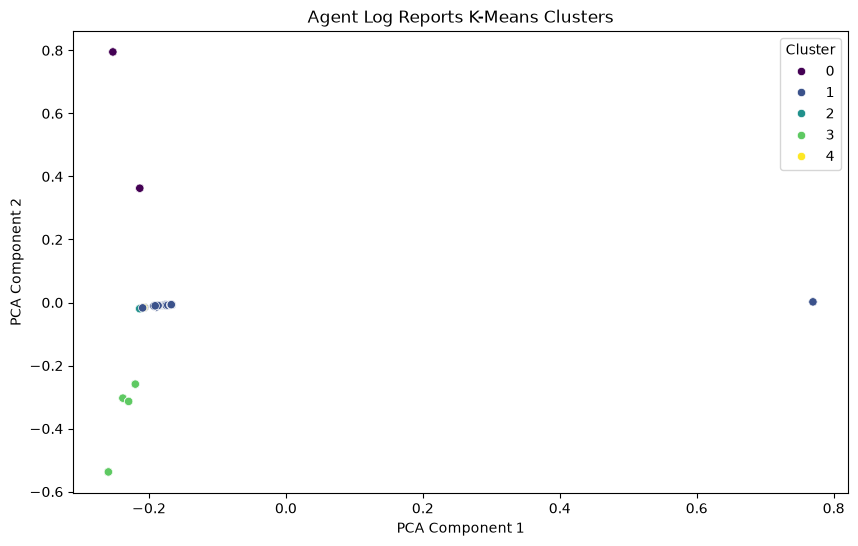

In [15]:
pca = PCA(
    n_components=2
)


reduced = pca.fit_transform(
    X.toarray()
)


plt.figure(figsize=(10,6))


sns.scatterplot(
    x=reduced[:,0],
    y=reduced[:,1],
    hue=df['Cluster'],
    palette='viridis'
)


plt.title(
    "Agent Log Reports K-Means Clusters"
)


plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")


plt.show()

In [16]:
for cluster in sorted(df['Cluster'].unique()):
    
    print("\n===================")
    print("CLUSTER:", cluster)
    print("===================")
    
    display(
        df[df['Cluster']==cluster]
        [['combined_text']]
        .head(5)
    )


CLUSTER: 0


,combined_text
2,Nandani Gupta 30-Jul-22 15:04:24 17:31:07 02:2...
48,Deepranjan Gupta 29-Jul-22 21:02:24 03:07:02 0...
67,Deepranjan Gupta 29-Jul-22 18:59:08 20:02:55 0...
84,Nandani Gupta 29-Jul-22 15:41:31 21:02:48 05:2...
87,Deepranjan Gupta 29-Jul-22 15:19:37 16:44:55 0...



CLUSTER: 1


,combined_text
0,Shivananda Sonwane 30-Jul-22 15:35:29 17:39:39...
1,Khushboo Priya 30-Jul-22 15:06:59 15:07:16 00:...
3,Hrisikesh Neogi 30-Jul-22 14:34:29 15:19:35 00...
4,Mukesh 30-Jul-22 14:03:15 15:11:52 01:08:36
5,Sowmiya Sivakumar 30-Jul-22 14:03:11 15:05:37 ...



CLUSTER: 2


,combined_text
695,Saurabh Shukla 23-Jul-22 08:35:20 09:18:20 00:...
698,Saurabh Shukla 22-Jul-22 23:24:41 23:26:41 00:...
703,Saurabh Shukla 22-Jul-22 22:33:16 22:35:17 00:...
706,Saurabh Shukla 22-Jul-22 21:43:03 21:45:03 00:...
709,Saurabh Shukla 22-Jul-22 21:08:56 21:10:56 00:...



CLUSTER: 3


,combined_text
11,Ishawant Kumar 30-Jul-22 13:05:35 13:12:45 00:...
47,Ishawant Kumar 29-Jul-22 21:03:31 03:04:35 06:...
63,Ishawant Kumar 29-Jul-22 19:24:30 19:29:11 00:...
64,Ishawant Kumar 29-Jul-22 19:12:12 19:15:02 00:...
81,Ishawant Kumar 29-Jul-22 16:04:55 16:07:35 00:...



CLUSTER: 4


,combined_text
55,Mahesh Sarade 29-Jul-22 20:08:50 21:08:35 00:5...
75,Mahesh Sarade 29-Jul-22 17:43:21 20:08:05 02:2...
94,Mahesh Sarade 29-Jul-22 14:58:50 17:40:43 02:4...
252,Mahesh Sarade 27-Jul-22 23:58:04 00:01:33 00:0...
254,Mahesh Sarade 27-Jul-22 23:30:49 23:55:14 00:2...


In [17]:
df.to_csv(
    "AgentLogingReport_KMeans_NLP_Clusters.csv",
    index=False
)